In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.19.0
Keras version: 3.13.2


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [3]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.InputLayer((28, 28, 1)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='tanh'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist = model.fit(x_train, y_train, batch_size=2048, epochs=100, validation_data=(x_test, y_test), verbose=2)

Epoch 1/100
30/30 - 3s - 98ms/step - loss: 1.2027 - sparse_categorical_accuracy: 0.7017 - val_loss: 0.6940 - val_sparse_categorical_accuracy: 0.8491
Epoch 2/100
30/30 - 0s - 8ms/step - loss: 0.6142 - sparse_categorical_accuracy: 0.8525 - val_loss: 0.5126 - val_sparse_categorical_accuracy: 0.8728
Epoch 3/100
30/30 - 0s - 10ms/step - loss: 0.4988 - sparse_categorical_accuracy: 0.8714 - val_loss: 0.4444 - val_sparse_categorical_accuracy: 0.8842
Epoch 4/100
30/30 - 0s - 8ms/step - loss: 0.4453 - sparse_categorical_accuracy: 0.8819 - val_loss: 0.4055 - val_sparse_categorical_accuracy: 0.8917
Epoch 5/100
30/30 - 0s - 11ms/step - loss: 0.4131 - sparse_categorical_accuracy: 0.8875 - val_loss: 0.3809 - val_sparse_categorical_accuracy: 0.8966
Epoch 6/100
30/30 - 1s - 18ms/step - loss: 0.3910 - sparse_categorical_accuracy: 0.8927 - val_loss: 0.3639 - val_sparse_categorical_accuracy: 0.8992
Epoch 7/100
30/30 - 0s - 12ms/step - loss: 0.3746 - sparse_categorical_accuracy: 0.8959 - val_loss: 0.3505 -

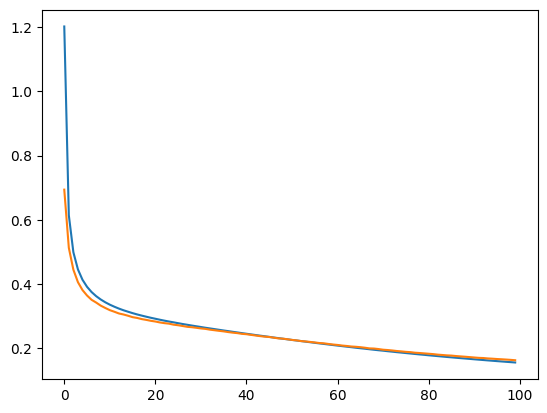

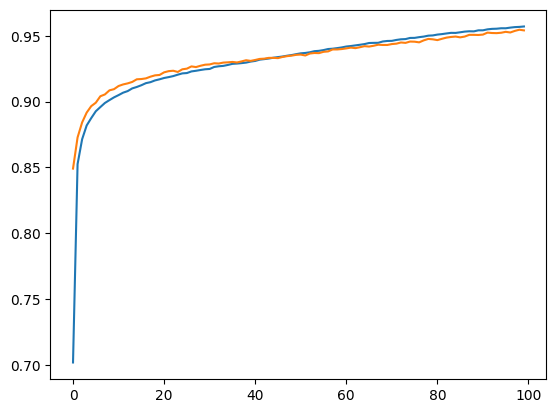

In [5]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.show()
plt.clf()
plt.plot(hist.history['sparse_categorical_accuracy'])
plt.plot(hist.history['val_sparse_categorical_accuracy'])
plt.show()

In [6]:
res = model.evaluate(x_test, y_test, batch_size=2048)
print(res)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1621 - sparse_categorical_accuracy: 0.9542 
[0.16208875179290771, 0.954200029373169]
